# Algo 3: Unified Inference with Disentangled Rejection

## BoT-IoT | Reuse Day-16 Checkpoint + L_φ | Reuse Day-19 q | Target (y) = "label_multiclass" | Data Reupload = 2 | All X_test Samples | All X_zero Samples

## $ ρ(x) \rightarrow F_{c} \rightarrow s=1−F_{max} \rightarrow \text{conformal} \rightarrow \text{label} + \text{certified radius} $

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_ALPHA, DEFAULT_BATCH_SIZE, DEFAULT_CF, DEFAULT_LAMBDA1, DEFAULT_LAMBDA2,
    DEFAULT_LR, DEFAULT_NOISE_RATE, ZERO_DAY, DEFAULT_SEED
)
from scripts.data import (
    capped_sample, load_split,
    plot_class_balance_pie, stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.conformal import calibrate_threshold
from scripts.prototypes import prototype_summary
from scripts.logging import write_history_log
from scripts.inference import qsnet_infer_batch, qsnet_infer_single, estimate_lipschitz
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y
from scripts.theory import analytic_lipschitz_bound, estimate_lipschitz_percentile, check_lipschitz_tightness

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: BoT-IoT

In [4]:
NOTEBOOK_NAME = "22.e2e-algo3_bot-iot.ipynb"
DAY16_NOTEBOOK = "16.estimate-lipschitz_bot-iot"
DAY19_NOTEBOOK = "19.fgsm-pgd-robustness_bot-iot"

dataset = "BoT-IoT"
data_path = f"data/{dataset}/quantum"
target_col = "label_multiclass"
split_prefix = "q8"

torch.manual_seed(42)
np.random.seed(42)

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0000,0.295669,0.000000,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0000,0.404791,0.000000,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0000,0.458797,0.000000,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0000,0.186546,0.000000,0.483341,0.186546,DoS,1,dos
...,...,...,...,...,...,...,...,...,...,...,...
130133,0.051554,0.337622,0.054277,0.0000,0.109122,0.000000,0.401096,0.109122,DDoS,1,ddos
130134,0.077777,0.495858,0.081885,0.0000,0.482215,0.000000,0.555750,0.482215,DDoS,1,ddos
130135,0.085139,0.332164,0.089636,0.0000,0.295669,0.000000,0.395761,0.295669,DDoS,1,ddos
130136,0.034507,0.527890,0.036329,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,0.030780,0.332164,0.032406,0.0000,0.295669,0.000000,0.395761,0.295669,DoS,1,dos
1,0.040153,0.429708,0.042274,0.0000,0.404791,0.000000,0.491098,0.404791,DoS,1,dos
2,0.114465,0.476056,0.120511,0.0000,0.458797,0.000000,0.536396,0.458797,DDoS,1,ddos
3,0.051103,0.527890,0.053802,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos
4,0.018999,0.421771,0.020003,0.0000,0.186546,0.000000,0.483341,0.186546,DoS,1,dos
...,...,...,...,...,...,...,...,...,...,...,...
130133,0.051554,0.337622,0.054277,0.0000,0.109122,0.000000,0.401096,0.109122,DDoS,1,ddos
130134,0.077777,0.495858,0.081885,0.0000,0.482215,0.000000,0.555750,0.482215,DDoS,1,ddos
130135,0.085139,0.332164,0.089636,0.0000,0.295669,0.000000,0.395761,0.295669,DDoS,1,ddos
130136,0.034507,0.527890,0.036329,0.0000,0.295669,0.000000,0.587057,0.295669,DDoS,1,ddos


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['DDoS', 'DoS', 'Normal', 'Reconnaissance']

In [8]:
# load all data
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, f"{split_prefix}_val", target_col, class_names)
X_cal_full, y_cal_full = load_split(data_path, f"{split_prefix}_calibration", target_col, class_names)
X_test_full, y_test_full = load_split(data_path, f"{split_prefix}_test", target_col, class_names)
X_zero_full, y_zero_full = load_split(data_path, f"{split_prefix}_zeroday", target_col, class_names)

# check shape
print(f"train : {X_train_full.shape, y_train_full.shape}\n\
val   : {X_val_full.shape, y_val_full.shape}\n\
cal   : {X_cal_full.shape, y_cal_full.shape}\n\
test  : {X_test_full.shape, y_test_full.shape}\n\
zero  : {X_zero_full.shape, y_zero_full.shape}"
)

train : ((130138, 8), (130138,))
val   : ((18591, 8), (18591,))
cal   : ((18591, 8), (18591,))
test  : ((18591, 8), (18591,))
zero  : ((683, 8), (683,))


## EDA (Before Subset)

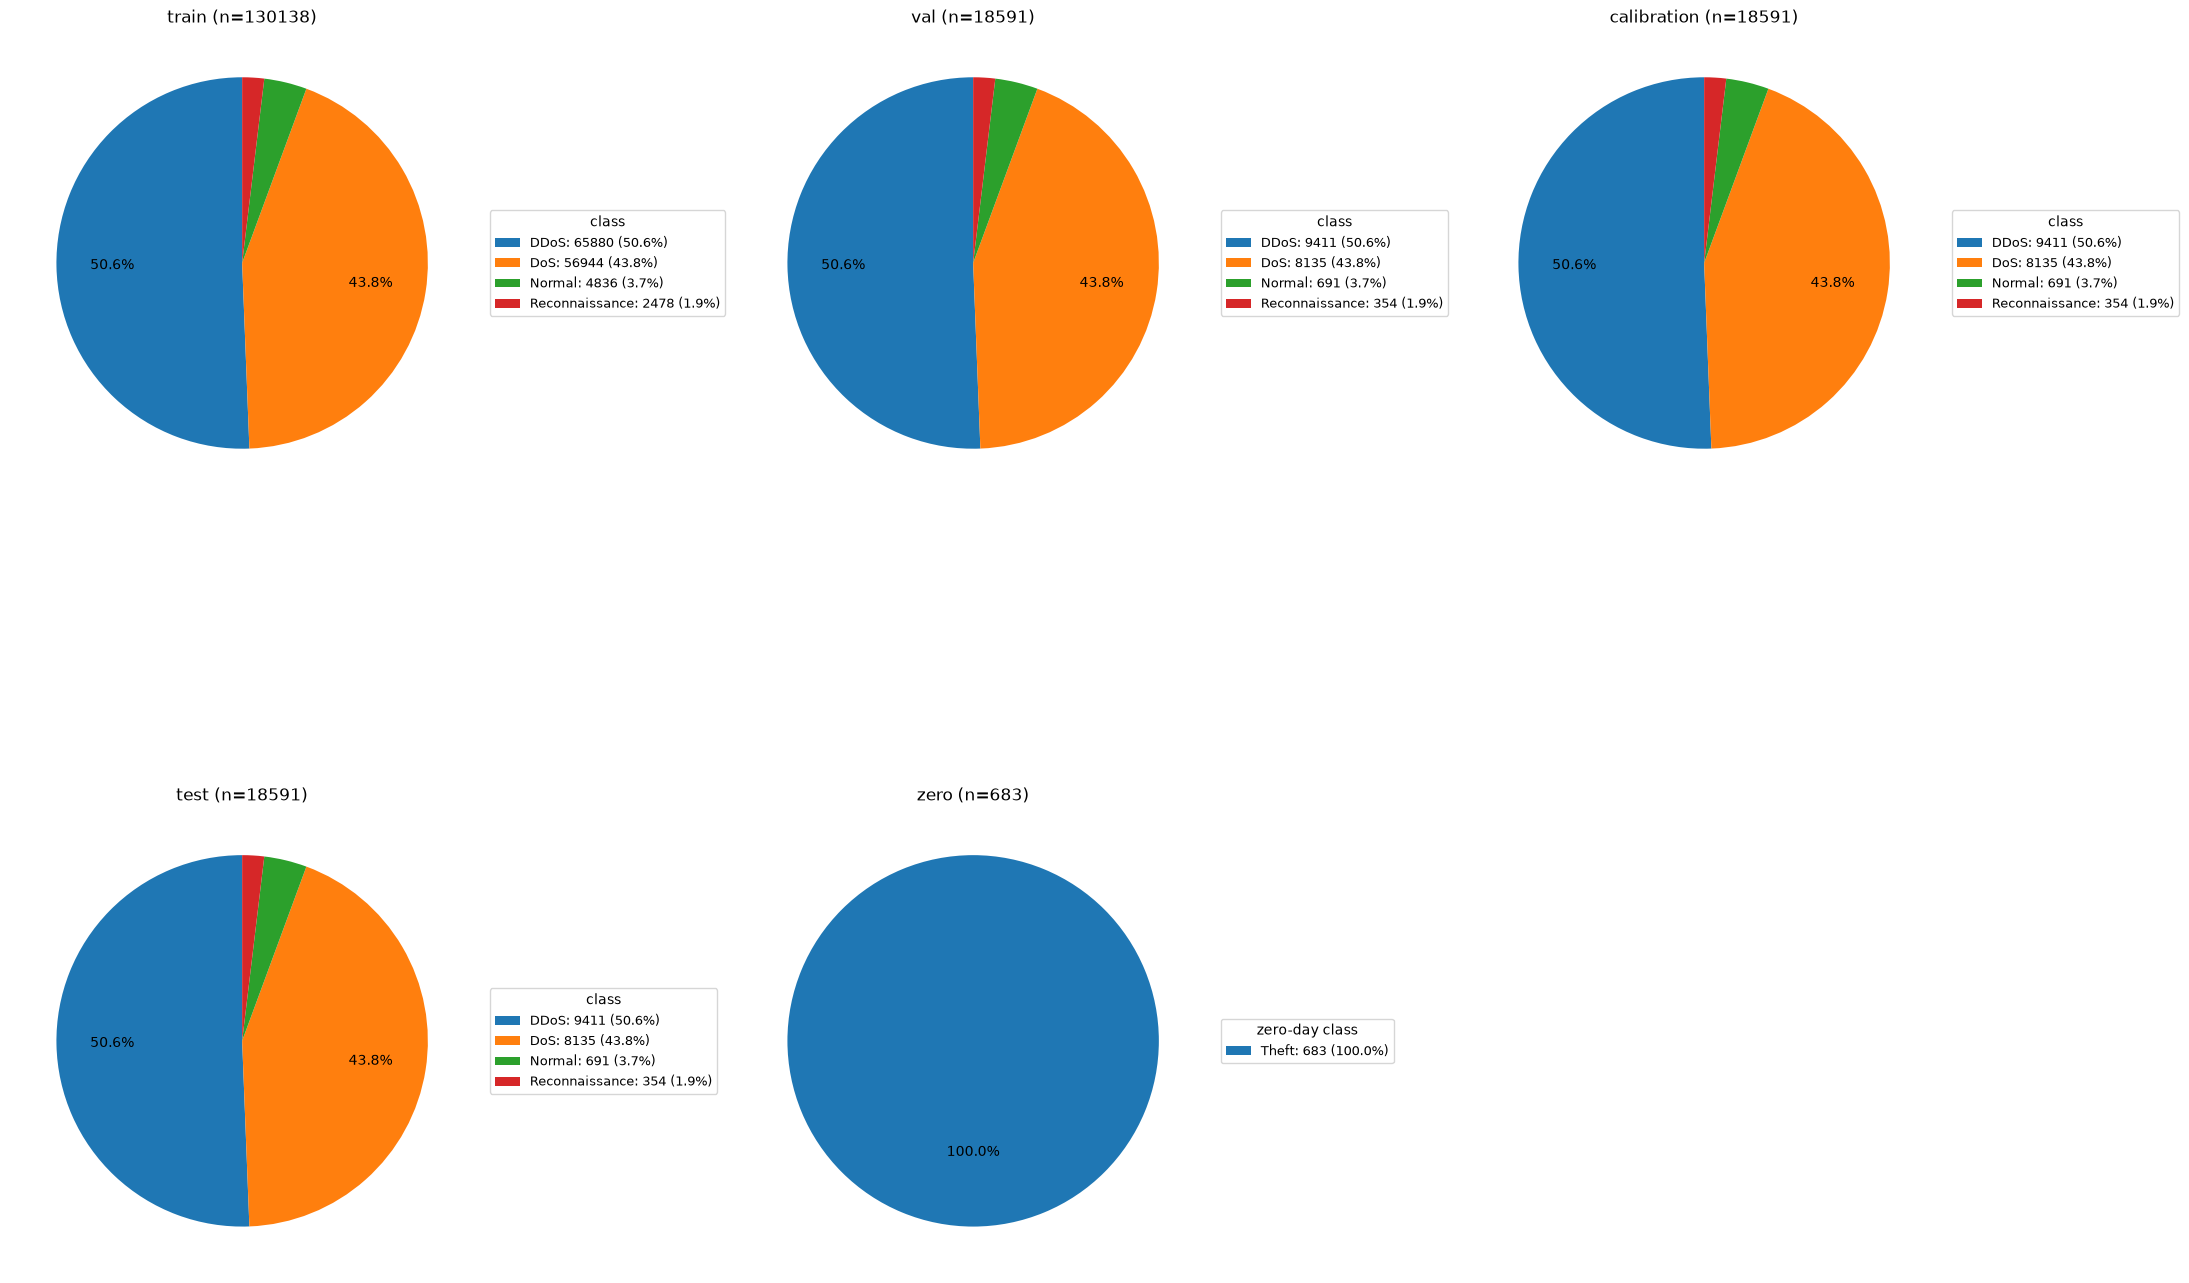

In [9]:
splits = {
    "train": y_train_full,
    "val": y_val_full,
    "calibration": y_cal_full,
    "test": y_test_full,
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero_full)

## reload just for EDA
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero = df_zero[df_zero[target_col].notna()].reset_index(drop=True)

vc = df_zero[target_col].value_counts()
ax.pie(vc.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 1 else "", startangle=90)
ax.legend(
    [f"{lab}: {n} ({100*n/vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero)})")

# remove extra chart
for ax in axes[len(splits) + 1:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Data Subset

In [10]:
SUBSET = True  # set to False for the full dataset
MORE_SUBSET = False
SEED = 42
PER_CLASS_CAP = 700  # matches Day-16 BoT-IoT protocol

In [11]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

if MORE_SUBSET is True:
    X_val, y_val = stratified_head(X_val_full, y_val_full, 400, seed=SEED)
    X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 400, seed=SEED)
    X_test, y_test = stratified_head(X_test_full, y_test_full, 400, seed=SEED)
    X_zero, y_zero, idx_zero = stratified_head(X_zero_full, y_zero_full, 40, seed=SEED, return_index=True)
else:
    X_val, y_val = X_val_full, y_val_full
    X_cal, y_cal = X_cal_full, y_cal_full
    X_test, y_test = X_test_full, y_test_full
    X_zero, y_zero = X_zero_full, y_zero_full
    idx_zero = np.arange(len(X_zero))

# check shape
print(f"train : {X_train.shape, y_train.shape}\n\
val   : {X_val.shape, y_val.shape}\n\
cal   : {X_cal.shape, y_cal.shape}\n\
test  : {X_test.shape, y_test.shape}\n\
zero  : {X_zero.shape, y_zero.shape}"
)

train : ((2800, 8), (2800,))
val   : ((18591, 8), (18591,))
cal   : ((18591, 8), (18591,))
test  : ((18591, 8), (18591,))
zero  : ((683, 8), (683,))


## EDA (After Subset)

In [12]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 4
number of qubits: 8


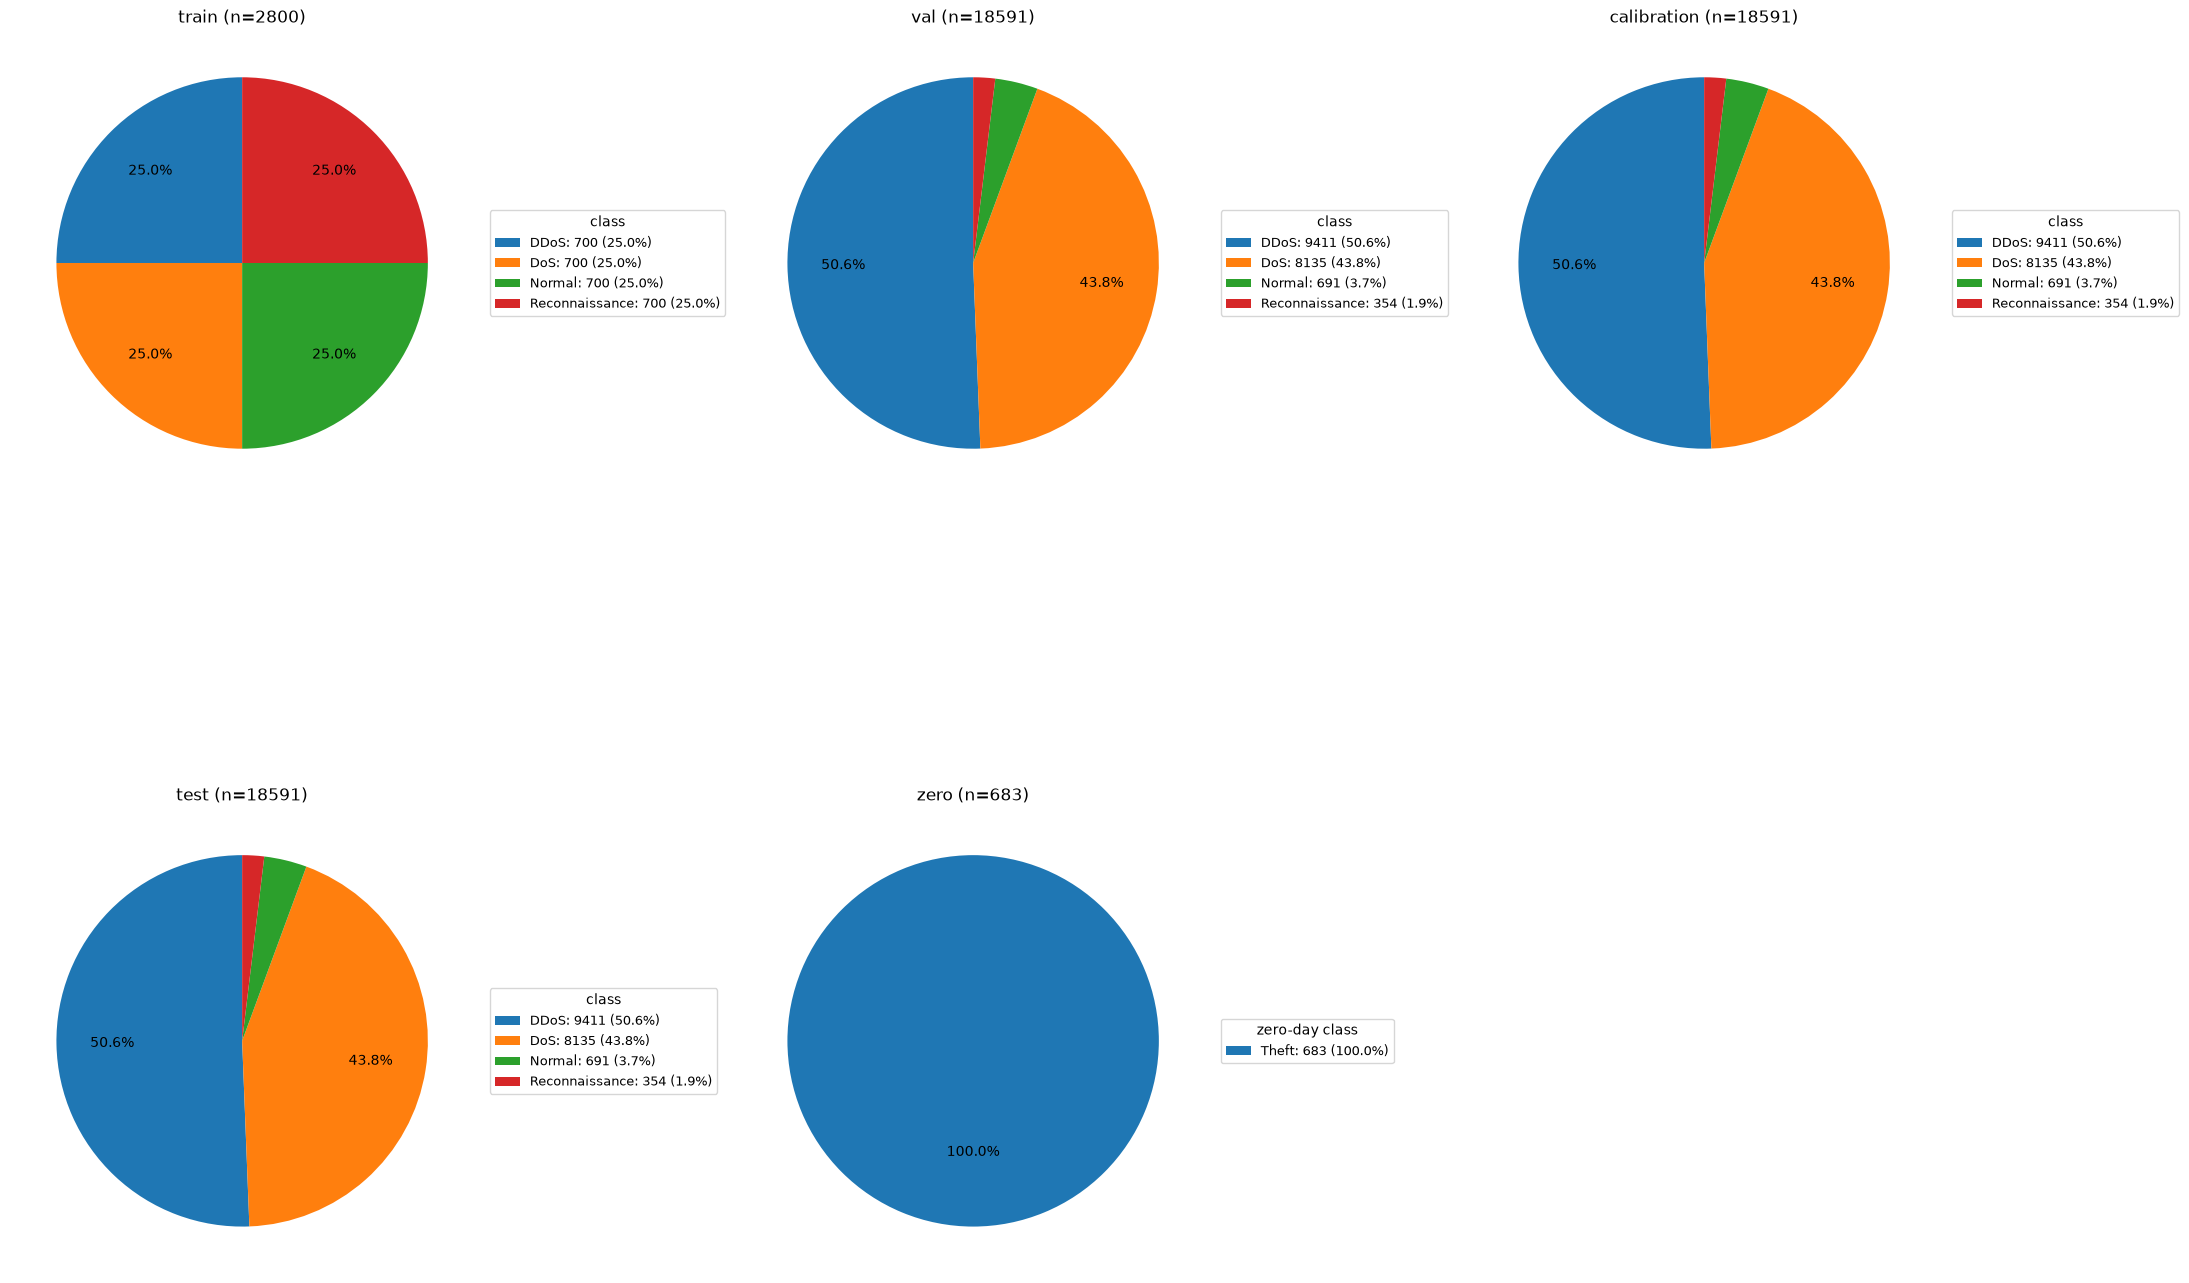

In [13]:
splits = {
    "train": y_train,
    "val": y_val,
    "calibration": y_cal,
    "test": y_test,
}

fig, axes = plt.subplots(2, 3, figsize=(22, 16))
axes = axes.ravel()

# train, val, cal, test
for ax, (name, y) in zip(axes, splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_y(y))})", ax=ax)

# zero-day
## show its own labels (not known class_names)
ax = axes[len(splits)]
y0 = to_np_y(y_zero)

## reload just for EDA
df_zero_subset = df_zero.reset_index(drop=True).iloc[idx_zero]
vc = df_zero_subset[target_col].value_counts()
ax.pie(vc.values, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 1 else "", startangle=90)
ax.legend(
    [f"{lab}: {n} ({100*n/vc.sum():.1f}%)" for lab, n in vc.items()],
    title="zero-day class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
)
ax.set_title(f"zero (n={len(df_zero_subset)})")

# remove extra chart
for ax in axes[len(splits) + 1:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [14]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [15]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Load Day-16 Encoder + $L_\varphi$

This notebook reuses the Day-16 MAQT checkpoint ($\theta^\star$, prototypes) and the published $L_\varphi$ artifact.

Set `LOAD_CHECKPOINT = False` only to retrain as a fallback.

In [16]:
# Day-16 model checkpoint
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY16_NOTEBOOK}-checkpoint.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2
seed = DEFAULT_SEED # 42

In [17]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))

    # rebuild circuit if checkpoint meta differs
    forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train, y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

loaded checkpoint: artifacts/BoT-IoT/16.estimate-lipschitz_bot-iot-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 4


In [18]:
# Day-16 L_phi (required for eps*)
LOAD_LPHI = True
LPHI_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY16_NOTEBOOK}-lphi.pt",
]

n_pairs = 200
percentile = 95

In [19]:
lphi_path = next((p for p in LPHI_CANDIDATES if p.exists()), None)

if LOAD_LPHI and lphi_path is not None:
    lphi_art = torch.load(lphi_path, map_location="cpu", weights_only=False)
    L_phi_estimated = float(lphi_art["L_phi_estimated"])
    L_phi_analytic = float(lphi_art["L_phi_analytic"])
    L_phi_percentile = float(lphi_art["L_phi_percentile"])

    # prefer analytic R/2 bound for L_phi
    L_phi = L_phi_analytic if np.isfinite(L_phi_analytic) else L_phi_estimated
    print(f"loaded L_phi from: {lphi_path}")
    print(f"L_phi analytic={L_phi_analytic:.4f} | estimated(p{L_phi_percentile:g})={L_phi_estimated:.4f}")
else:
    print("ERROR: cannot load L_phi as artifact is missing!")
    # certificate
    L_phi = analytic_lipschitz_bound(num_layers, reupload=True)

    # diagnostic (optional)
    # tightness_diagnostic = estimate_lipschitz_percentile(
    #     X_train, theta_star, forward_circuit,
    #     n_pairs=n_pairs, device=device, percentile=percentile, seed=seed,
    # )
    # print(check_lipschitz_tightness(diag, L_phi))

print(f"using L_phi={L_phi:.4f} for certified radius")

loaded L_phi from: artifacts/BoT-IoT/16.estimate-lipschitz_bot-iot-lphi.pt
L_phi analytic=1.0000 | estimated(p95)=0.6792
using L_phi=1.0000 for certified radius


## Load Day-19 Conformal Zero-Day Threshold Calibration (q)

- Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.
- Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

This notebook reuses the Day-19 artifact.

Set `LOAD_Q = False` only to recalibrate $q$ as a fallback.

In [20]:
# Day-19 artifact
LOAD_Q = True
Q_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY19_NOTEBOOK}-artifact.pt",
]

alpha = DEFAULT_ALPHA

In [21]:
q_path = next((p for p in Q_CANDIDATES if p.exists()), None)
q_source = None
scores_sorted = None

if LOAD_Q and q_path is not None:
    day19 = torch.load(q_path, map_location="cpu", weights_only=False)
    q = float(day19["q"])
    alpha = float(day19["alpha"])
    q_source = str(q_path)
    print(f"loaded q from Day-19: q={q:.6f} (alpha={alpha})")
else:
    print("ERROR: cannot load q as artifact is missing; recalibrating q on X_cal")
    q, scores_sorted = calibrate_threshold(
        theta_star, X_cal, prototypes, forward_circuit,
        alpha=alpha, device=device, batch_size=batch_size,
    )
    q_source = "just calibrated with calibrate_threshold(X_cal)"
    print(f"calibrated q={q:.6f} (alpha={alpha}, n_cal={len(X_cal)})")

loaded q from Day-19: q=0.124075 (alpha=0.05)


## Evaluation on Known Test Samples

In [22]:
Cf = DEFAULT_CF
zero_day = ZERO_DAY
p = noise_rate

print(f"p       : {p}")
print(f"L_phi   : {L_phi:.4f}")
print(f"C_f     : {Cf}")
print(f"q       : {q:.6f}")

p       : 0.01
L_phi   : 1.0000
C_f     : 1.0
q       : 0.124075


In [23]:
y_pred, radii, novelty_scores, f_maps = qsnet_infer_batch(
    X_test, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)
y_test_np = to_np_y(y_test).astype(int)
label_ids = list(range(num_classes))

[pipeline] mean certified radius (accepted): 0.0076

[pipeline] classification report (accepted only):
                precision    recall  f1-score   support

          DDoS       0.55      0.89      0.68      9156
           DoS       0.55      0.15      0.24      7783
        Normal       0.00      0.00      0.00       328
Reconnaissance       0.61      0.97      0.75       282

      accuracy                           0.55     17549
     macro avg       0.43      0.50      0.42     17549
  weighted avg       0.54      0.55      0.47     17549



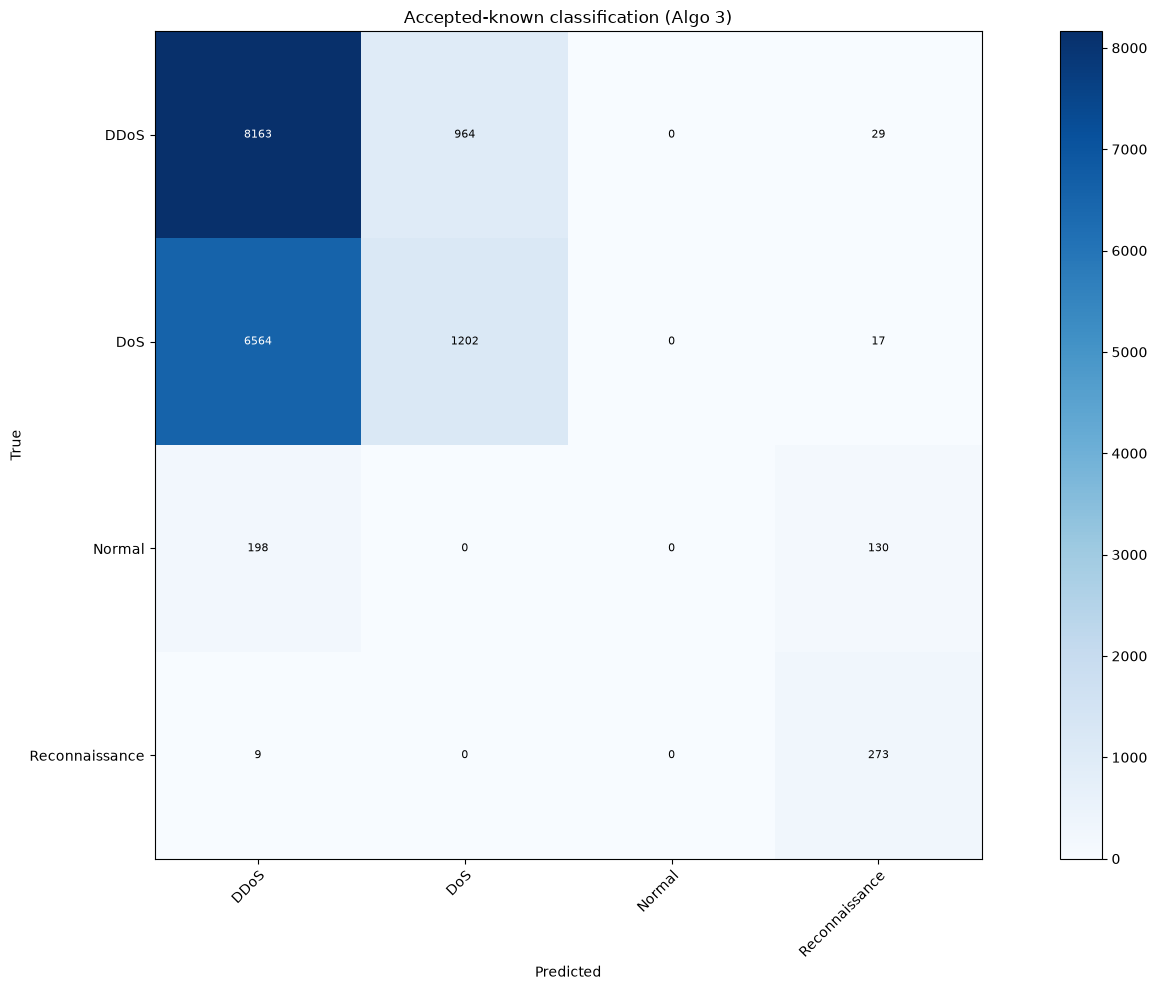

In [24]:
known_mask = y_pred != ZERO_DAY
pipeline_reject_rate = float(1.0 - known_mask.mean())
pipeline_acc = float(np.mean(y_pred[known_mask] == y_test_np[known_mask])) if known_mask.any() else 0.0
pipeline_macro_f1 = float(
    f1_score(y_test_np[known_mask], y_pred[known_mask], average="macro", labels=label_ids, zero_division=0)
)
pipeline_radius_mean = float(radii[known_mask].mean()) if known_mask.any() else float('nan')

print(f"[pipeline] mean certified radius (accepted): {pipeline_radius_mean:.4f}")

if known_mask.any():
    print("\n[pipeline] classification report (accepted only):")
    print(classification_report(
        y_test_np[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test_np[known_mask], y_pred[known_mask], labels=label_ids)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="Accepted-known classification (Algo 3)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # annotate counts
    thresh = cm.max() / 2.0 if cm.size and cm.max() > 0 else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## Evaluation on Zero-Day Samples

In [25]:
df_zero_subset

,rate,n_bytes_total,rate_src,dst_pkts,n_pkts_total,dst_bytes,src_bytes,src_pkts,label_multiclass,label_binary,label_family
0,1.930101,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
1,1.964597,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
2,1.969794,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
3,1.391540,0.612713,1.299625,0.484059,0.482215,1.090129,0.515005,0.337155,Theft,1,theft_exfiltration
4,2.079034,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
...,...,...,...,...,...,...,...,...,...,...,...
678,1.254680,0.911693,1.181002,0.434803,0.458797,0.947530,0.950762,0.337155,Theft,1,theft_exfiltration
679,2.269998,0.408790,2.170553,0.374519,0.337155,0.904365,0.340159,0.186546,Theft,1,theft_exfiltration
680,1.816860,0.165308,0.000000,0.187260,0.109122,0.697155,0.113138,0.000000,Theft,1,theft_exfiltration
681,0.422707,0.951819,0.292256,0.809323,0.777883,1.401536,0.784051,0.575954,Theft,1,theft_exfiltration


In [26]:
y_zero_pred, radii_zero, scores_zero, _ = qsnet_infer_batch(
    X_zero, theta_star, prototypes, q, forward_circuit,
    p=p, L_phi=L_phi, Cf=Cf, zero_day=zero_day,
    device=device, batch_size=batch_size,
)

detected = y_zero_pred == ZERO_DAY
detection_rate = (detected).mean()

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

detected as ZERO_DAY: 682 / 683 (99.9%)
incorrectly accepted: 1
mean novelty score: 0.4142 | threshold q: 0.1241


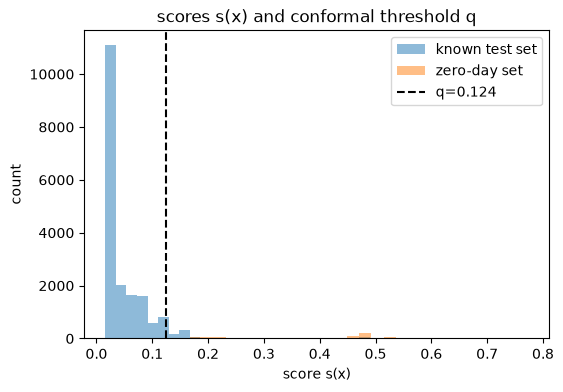

In [27]:
plt.figure(figsize=(6,4))
plt.hist(novelty_scores, bins=40, alpha=0.5, label="known test set")
plt.hist(scores_zero, bins=30, alpha=0.5, label="zero-day set")
plt.axvline(q, color="k", linestyle="--", label=f"q={q:.3f}")
plt.legend()
plt.xlabel("score s(x)")
plt.ylabel("count")
plt.title("scores s(x) and conformal threshold q")
plt.show()

## RQ1 Detection Numbers

In [28]:
TPR_zeroday = float(detection_rate)
FPR_known = float(pipeline_reject_rate)
class_acc_known = float(pipeline_acc)

print("=== RQ1 ===")
print(f"True Positive Rate (TPR_zeroday):  {TPR_zeroday:.4f}          # fraction of true zero-day rejected")
print(f"False Positive Rate (FPR_known):   {FPR_known:.4f}          # fraction of known wrongly rejected (target alpha={alpha})")
print(f"Accepted-known accuracy (class_acc_known): {class_acc_known:.4f}  # class accuracy on known samples Algo-3 accepted")
print(f"n_test={len(y_test_np)}")
print(f"n_zeroday={len(X_zero)}")

=== RQ1 ===
True Positive Rate (TPR_zeroday):  0.9985          # fraction of true zero-day rejected
False Positive Rate (FPR_known):   0.0560          # fraction of known wrongly rejected (target alpha=0.05)
Accepted-known accuracy (class_acc_known): 0.5492  # class accuracy on known samples Algo-3 accepted
n_test=18591
n_zeroday=683


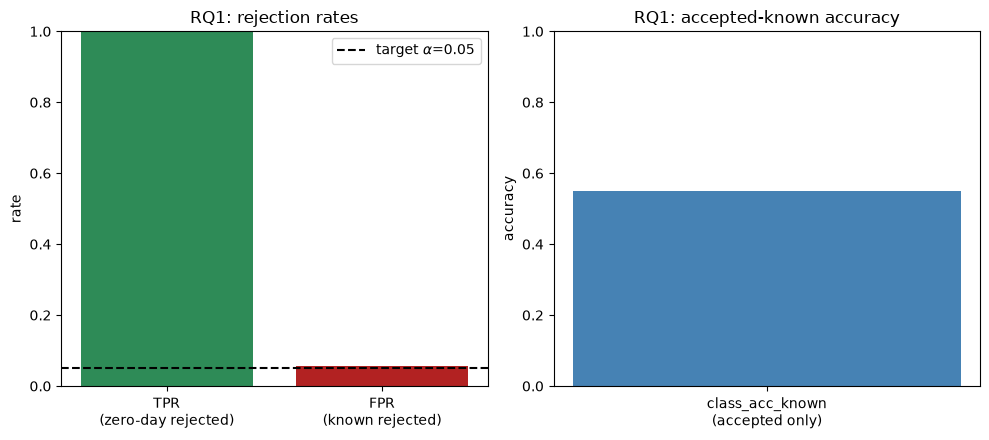

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# rejection rates
axes[0].bar(
    ["TPR\n(zero-day rejected)", "FPR\n(known rejected)"],
    [TPR_zeroday, FPR_known],
    color=["seagreen", "firebrick"],
)
axes[0].axhline(alpha, color="black", linestyle="--", label=fr"target $\alpha$={alpha}")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("rate")
axes[0].set_title("RQ1: rejection rates")
axes[0].legend()

# accepted-known accuracy
axes[1].bar(["class_acc_known\n(accepted only)"], [class_acc_known], color="steelblue")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("accuracy")
axes[1].set_title("RQ1: accepted-known accuracy")

plt.tight_layout()
plt.show()

## Logging

In [30]:
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

# publish artifact
artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path) if ckpt_path else None,
    "lphi_path": str(lphi_path) if lphi_path else None,
    "q_source": q_source,
    "q": float(q),
    "alpha": float(alpha),
    "L_phi": float(L_phi),
    "p": float(p),
    "C_f": float(Cf),
    "pipeline_reject_rate": float(pipeline_reject_rate),
    "pipeline_acc_accepted": float(pipeline_acc),
    "pipeline_macro_f1_accepted": float(pipeline_macro_f1),
    "pipeline_radius_mean_accepted": float(pipeline_radius_mean),
    "zeroday_detection_rate": float(detection_rate),
    "n_zeroday_eval": int(len(X_zero)),

    "RQ1": {
        "TPR_zeroday": TPR_zeroday,
        "FPR_known": FPR_known,
        "class_acc_known": class_acc_known,
        "alpha": float(alpha),
        "n_test": int(len(y_test_np)),
        "n_zeroday": int(len(X_zero)),
    },
}
torch.save(artifact, out_dir / f"{NOTEBOOK_NAME}-algo3.pt")
print("published:", (out_dir / f"{NOTEBOOK_NAME}-algo3.pt").resolve())

# write log (final)
write_history_log(
    history if history else {"radius_mean": [pipeline_radius_mean]},
    NOTEBOOK_NAME,
    extra=artifact,
    log_dir="logs",
)

published: /home/lawun330/Desktop/quantum-sentinel/artifacts/BoT-IoT/22.e2e-algo3_bot-iot.ipynb-algo3.pt


PosixPath('logs/22.e2e-algo3_bot-iot.ipynb.log')